In [538]:
import pandas as pd
import numpy as np
import seaborn as sns
import pm4py
import ast
import matplotlib.pyplot as plt
import scipy.stats as stats

In [539]:
# Load dataset
filepath = 'generated/preprocessed_dataset.csv'
df = pd.read_csv(filepath, parse_dates=["time:timestamp"])

df['case:concept:name'] = df['case:concept:name'].astype(str)
df['time:timestamp']= pd.to_datetime(df['time:timestamp'])

In [540]:
def find_best_inductive_miner_threashold(log, lower_bound=0.0, upper_bound=1.0, step=0.1):
    """
    Finds the best noise threshold for the Inductive Miner by evaluating the F1 
    score of the discovered Petri net against the log.

    Parameters
    ----------
    log : pandas.DataFrame
        The event log as a DataFrame.
    lower_bound : float, optional
        The lower bound of the noise threshold range (default is 0.0).
    upper_bound : float, optional
        The upper bound of the noise threshold range (default is 1.0).
    step : float, optional
        The step size for iterating over the noise threshold range (default is 0.1).
    """
    
    best_threshold = None
    best_f1 = -1
    
    thresholds = np.arange(lower_bound, upper_bound + step, step)

    for threshold in thresholds:
        net, im, fm = pm4py.discover_petri_net_inductive(log, noise_threshold=threshold)
        metrics = perform_metric(log, net, im, fm)

        print(f"Threshold: {threshold:.2f}, Fitness: {metrics['fitness']:.4f}, Precision: {metrics['precision']:.4f}, F1: {metrics['f1']:.4f}")
        
        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
            best_threshold = threshold

    print(f"Best Threshold: {best_threshold:.2f}, Best F1 Score: {best_f1:.4f}")

    return best_threshold, best_f1

In [541]:
def find_best_k_by_f1(log, k_values, activity_key='concept:name',
                      case_id_key='case:concept:name', timestamp_key='time:timestamp',
                      discovery_algo=pm4py.discover_petri_net_inductive, beta=1.0):
    """
    For a given event log, iteratively filter by top-k variants, discover a Petri net
    from each filtered log, compute fitness/precision/F1, and return the k with best F1.

    Parameters
    ----------
    log : pm4py.objects.log.obj.EventLog
    k_values : iterable of int
        k values to test (e.g., range(1,21))
    activity_key, case_id_key, timestamp_key : str
        Keys to pass to discovery (and used by pm4py functions)
    discovery_algo : callable
        Function used to discover the petri net. Must accept (log, activity_key=..., case_id_key=..., timestamp_key=...)
        and return (net, im, fm).

    Returns
    -------
    dict with:
      - best_k
      - baseline_full_log_f1
      - results: dict keyed by k with metrics
    """

    def discover_net_from(l):
        # discover and return net, im, fm for a given log
        return discovery_algo(l,
                              activity_key=activity_key,
                              case_id_key=case_id_key,
                              timestamp_key=timestamp_key)

    # --- Baseline on full log ---
    if len(log) == 0:
        raise ValueError("Input log is empty.")

    net_full, im_full, fm_full = discover_net_from(log)

    fitness_full = pm4py.fitness_token_based_replay(log, net_full, im_full, fm_full)
    fitness_full_value = fitness_full.get("average_trace_fitness", fitness_full.get("fitness", None))
    if fitness_full_value is None:
        # fallback if pm4py returns differently
        raise RuntimeError("Could not read fitness from fitness_token_based_replay result for full log.")

    precision_full_value = pm4py.precision_token_based_replay(log, net_full, im_full, fm_full)

    # Returns a list of activities (event names) that occur more than `threshold` times in the log.
    activities = pm4py.get_event_attribute_values(log, 'concept:name')
    threshold = 10
    frequent_activities = [act for act, freq in activities.items() if freq > threshold]
    # print(len(activities))
    # print(len(frequent_activities))
    
    # Beta is a factor to decide if prioritazing fitness or precision 
    # β > 1: prioritize recall (fitness in process mining)
    # β < 1: prioritize precision
    # β = 1: becomes the usual F1 score

    # The + 1e-12 is only a numerical safeguard to avoid division by zero.
    baseline_f1 = (1+ beta**2) * precision_full_value * fitness_full_value / (beta**2 * precision_full_value + fitness_full_value  + 1e-12)

    print("BASELINE (FULL LOG)")
    print(f"- events: {len(log)}")
    print(f"- cases: {len(log['case:concept:name'].unique())}")
    print(f"- frequent activities: {len(frequent_activities)} (with frequency treshold: {threshold}, total activities: {len(activities)})")
    print(f"- fitness: {fitness_full_value:.3f}")
    print(f"- precision: {precision_full_value:.3f}")
    print(f"- F1: {baseline_f1:.3f}\n")

    best_k = None
    best_f1 = -np.inf
    results = {}

    # --- Iterate over k values ---
    for k in k_values:
        rep_log = pm4py.filter_variants_top_k(log, k)

        # skip empty filtered logs
        if len(rep_log) == 0:
            print(f"[k={k}] filtered log is empty -> skipping")
            continue

        try:
            net_k, im_k, fm_k = discover_net_from(rep_log)
        except Exception as e:
            # discovery failed for this filtered log
            print(f"[k={k}] discovery failed: {e!r} -> skipping")
            continue

        # List all labeled transitions (i.e., visible activities)
        activities = [t.label for t in net_k.transitions if t.label is not None]      

        # compute metrics
        fitness_k = pm4py.fitness_token_based_replay(log, net_k, im_k, fm_k)
        fitness_k_value = fitness_k.get("average_trace_fitness", fitness_k.get("fitness", None))
        if fitness_k_value is None:
            print(f"[k={k}] could not read fitness value -> skipping")
            continue

        precision_k_value = pm4py.precision_token_based_replay(log, net_k, im_k, fm_k)

        f1_k = (1+ beta**2) * precision_k_value * fitness_k_value / (beta**2 * precision_k_value + fitness_k_value  + 1e-12)

        results[k] = {
            "fitness": fitness_k_value,
            "precision": precision_k_value,
            "f1": f1_k,
            "num_cases_coverage": (len(rep_log['case:concept:name'].unique()) / len(log['case:concept:name'].unique()))*100,
            "num_activities_in_net": len(activities)
        }
        if f1_k > best_f1:
            best_f1 = f1_k
            best_k = k

    # final summary
    if best_k is not None:
        print("\nBEST k:", best_k)
        print("metrics:", results[best_k])
    else:
        print("\nNo successful k produced metrics (all skipped or failed).")

    return {
        "best_k": best_k,
        "baseline_full_log_f1": baseline_f1,
        "results": results
    }

In [542]:
# Perform conformance checking using token-based replay
def perform_cc_tbr(log, petri_net, initial_marking, final_marking):
    diagnostic_df = pm4py.conformance_diagnostics_token_based_replay(log, petri_net, initial_marking, final_marking, return_diagnostics_dataframe=True)
    diagnostic_dic = pm4py.conformance_diagnostics_token_based_replay(log, petri_net, initial_marking, final_marking)
    diagnostic_ex = pd.DataFrame.from_dict(diagnostic_dic)
    return pd.merge(diagnostic_df, diagnostic_ex, left_index=True, right_index=True)

# Perform conformance checking using alignments
def perform_cc_al(log, petri_net, initial_marking, final_marking):
    diagnostic_df = pm4py.conformance_diagnostics_alignments(log, petri_net, initial_marking, final_marking, return_diagnostics_dataframe=True)
    diagnostic_dic = pm4py.conformance_diagnostics_alignments(log, petri_net, initial_marking, final_marking)
    diagnostic_ex = pd.DataFrame.from_dict(diagnostic_dic)
    return pd.merge(diagnostic_df, diagnostic_ex, left_index=True, right_index=True)

In [543]:
# Extract Problematic Transitions
def extract_problematic_transitions(df):
    # Parse the 'transitions_with_problems' column safely
    all_transitions = []
    for item in df['transitions_with_problems']:
        if isinstance(item, str):
            transitions = ast.literal_eval(item)
        else:
            transitions = item
        all_transitions.extend(transitions)
    
    return pd.Series(all_transitions).value_counts()

In [544]:
def classify_alignment(alignment):
    log_moves = []
    model_moves = []
    position_log = {}
    position_model = {}

    log_idx = 0
    model_idx = 0

    activity_status = []

    # First pass: Record positions and categorize basic moves (insert/skip)
    for event, transition in alignment:
        if transition is None:
            continue

        if event != '>>':
            log_moves.append(event)
            if event not in position_log:
                position_log[event] = log_idx
            log_idx += 1

        if transition != '>>':
            model_moves.append(transition)
            if transition not in position_model:
                position_model[transition] = model_idx
            model_idx += 1

        # Handle classification for sync, insert, and skip
        if event == transition and event != '>>':
            continue  # Sync move
        elif transition == '>>':
            # Insert: event in log but not in model
            activity_status.append(('insert', event))
        elif event == '>>':
            # Skip: transition in model but not in log
            activity_status.append(('skip', transition))

    # Refine classification to early/late where possible
    final_classification = []
    seen = set()

    for label, activity in activity_status:
        if activity in seen:
            continue  # Avoid duplicate classifications
        seen.add(activity)

        in_log = activity in position_log
        in_model = activity in position_model

        if in_log and in_model:
            if position_log[activity] < position_model[activity]:
                final_classification.append(('early', activity))
            elif position_log[activity] > position_model[activity]:
                final_classification.append(('late', activity))
        elif label == 'insert':
            final_classification.append(('insert', activity))
        elif label == 'skip':
            final_classification.append(('skip', activity))

    return final_classification

def apply_classification(df):
    copy_df = df.copy()
    copy_df['classified_alignment'] = copy_df['alignment'].apply(classify_alignment)
    return copy_df

<Axes: xlabel='concept:name', ylabel='case:concept:name'>

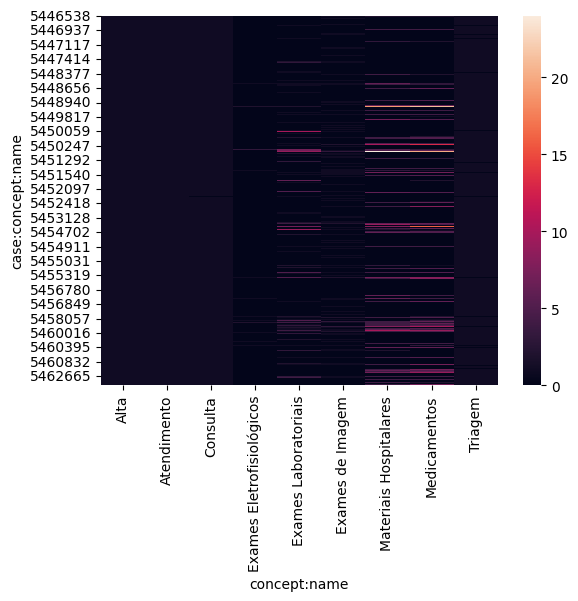

In [545]:
# Create a table giving the number of cases in which each activity is present
activity_frequency = pd.crosstab(df['case:concept:name'], df['concept:name'])
activity_frequency.sort_index(key=lambda x: x.astype(int), inplace=True)

sns.heatmap(activity_frequency)

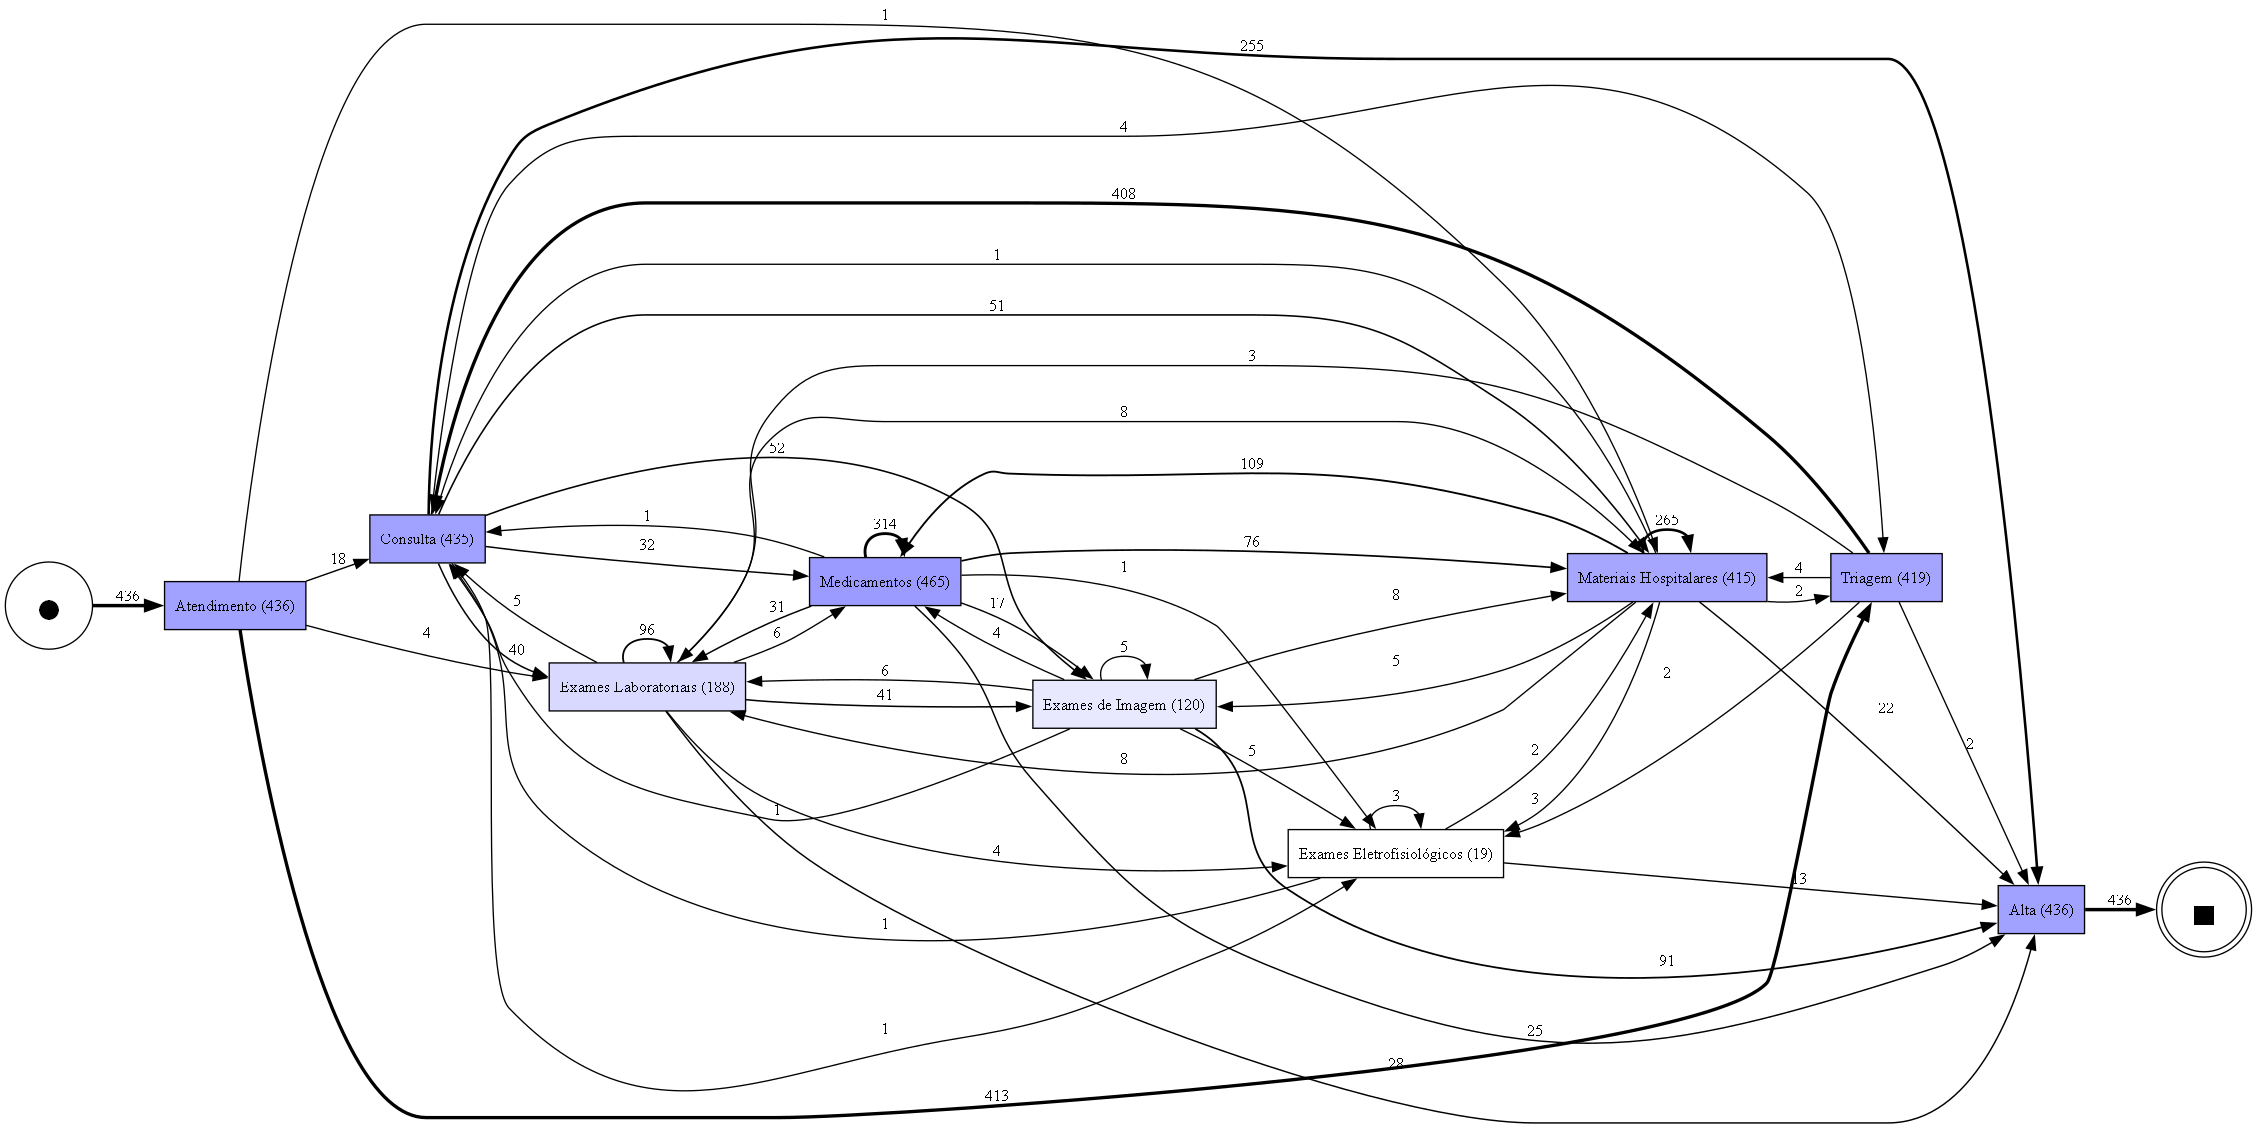

In [546]:
# Discovers a Directly-Follows Graph (DFG) from the log
dfg, start_activities, end_activities = pm4py.discover_dfg(df)

pm4py.view_dfg(dfg, start_activities, end_activities, format='png')

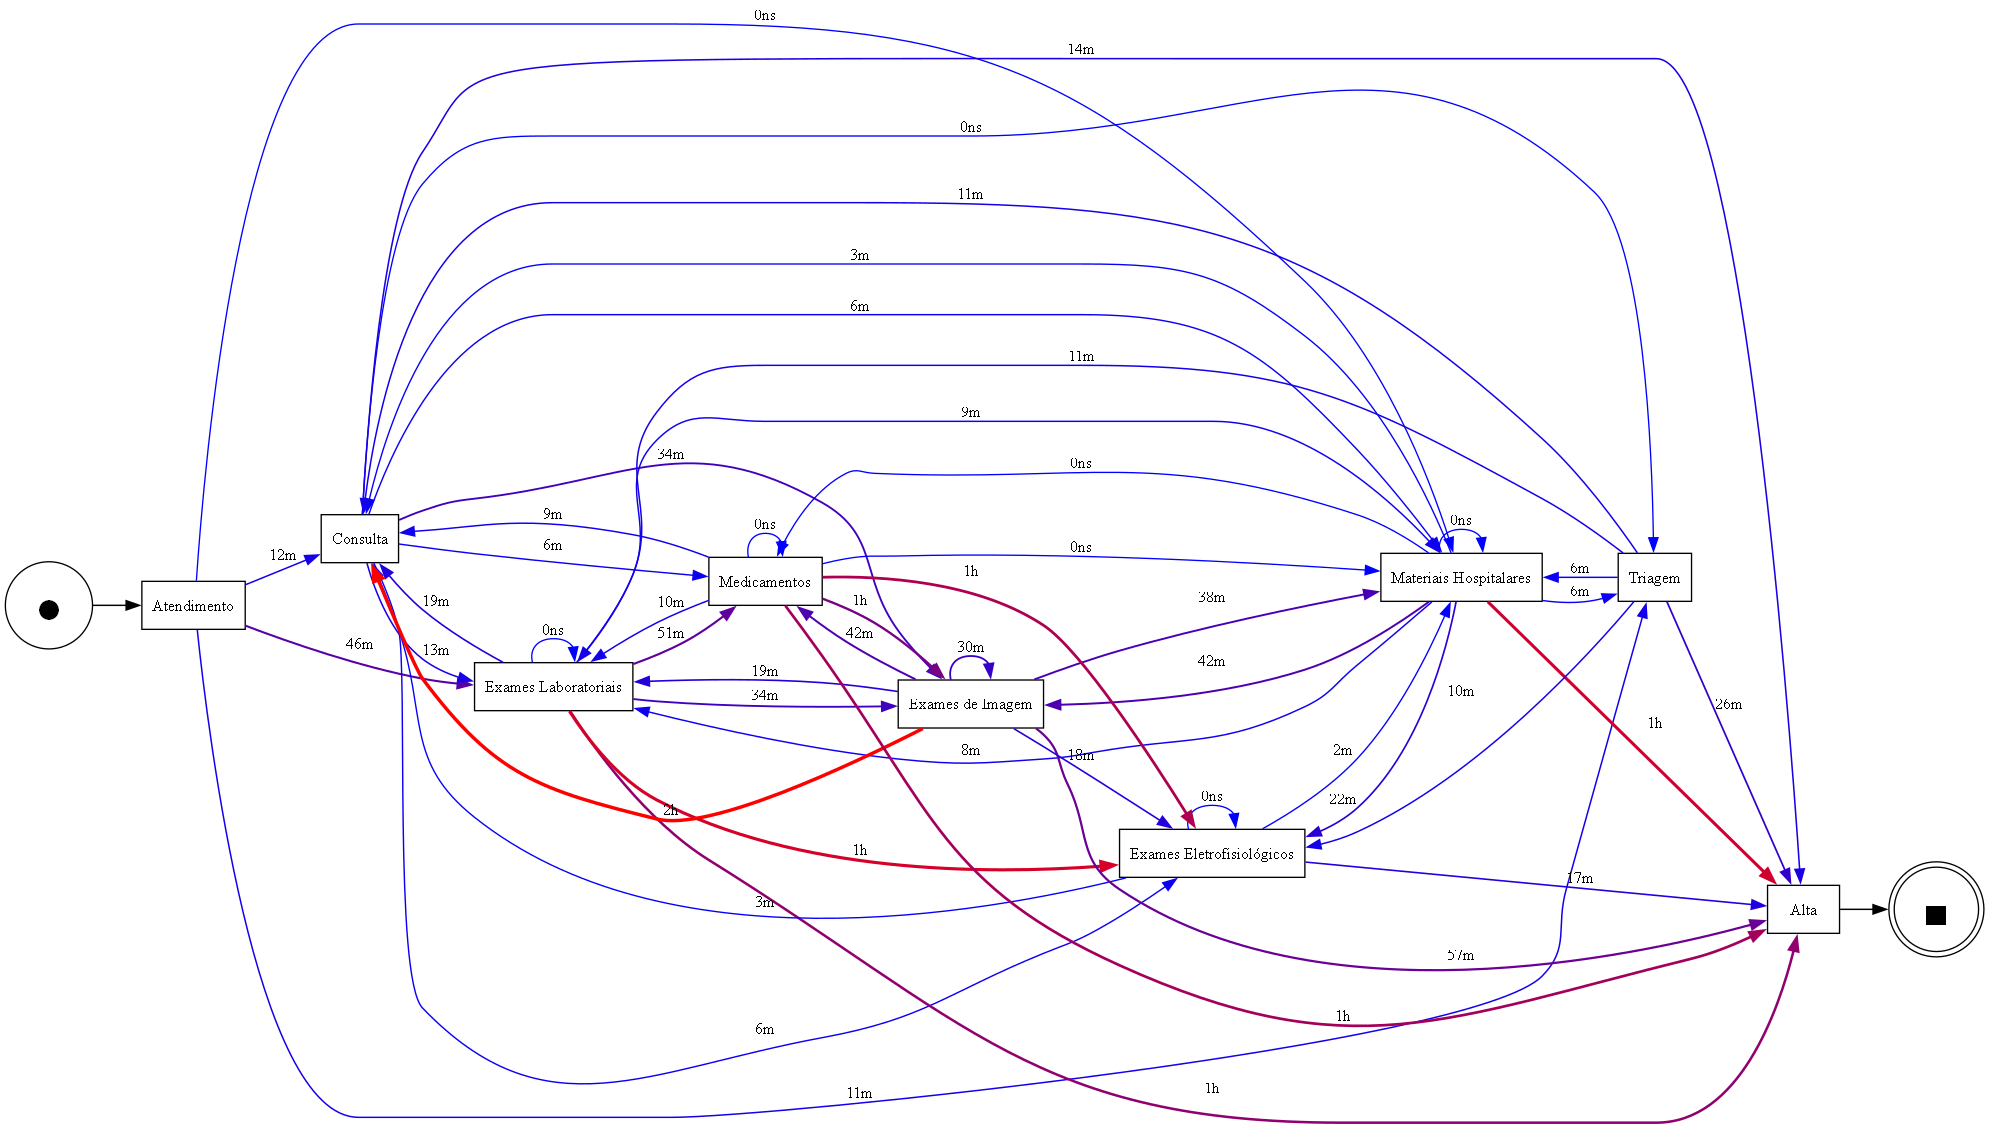

In [547]:
# Dicover and View a performance DFG
performance_dfg, sa, ea = pm4py.discover_performance_dfg(df)

pm4py.view_performance_dfg(performance_dfg, sa, ea, format='png', aggregation_measure='median')

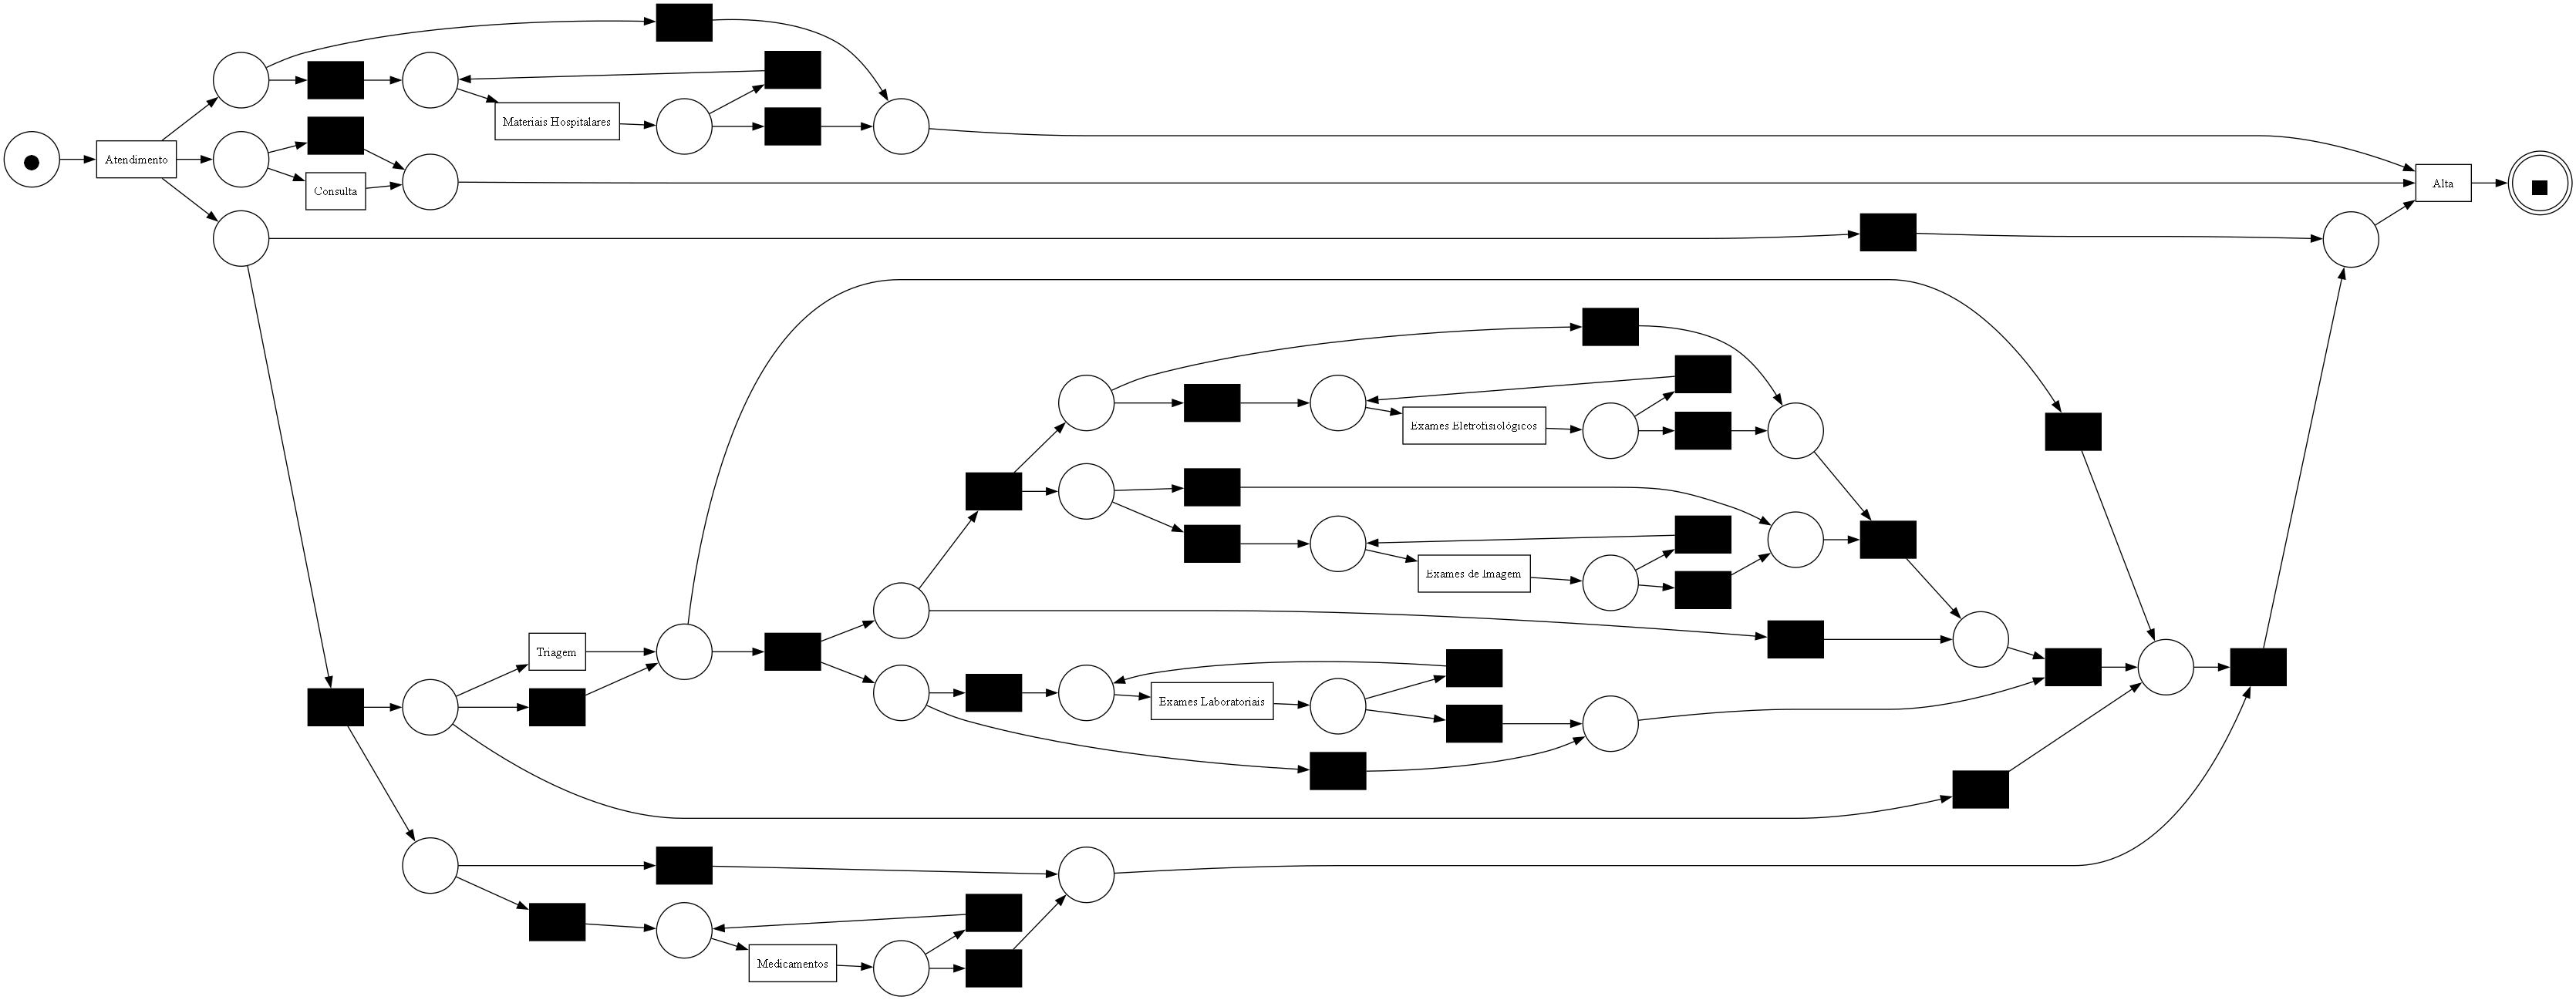

In [548]:
net_inlier_ind, im_inlier_ind, fm_inlier_ind = pm4py.discover_petri_net_inductive(df)

pm4py.view_petri_net(net_inlier_ind, im_inlier_ind, fm_inlier_ind, format='png')

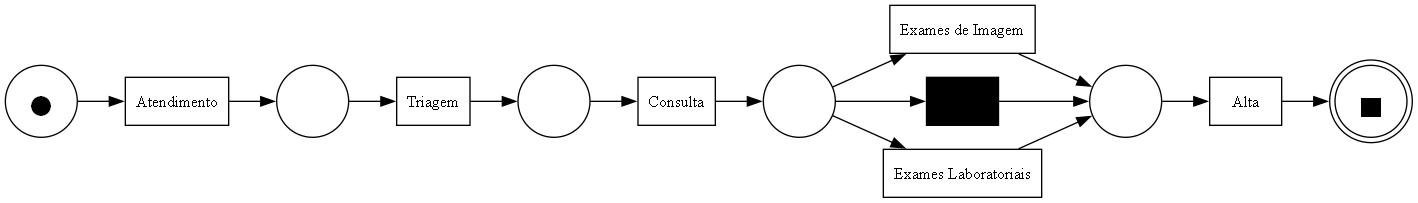

In [549]:
# Top 3 variant model
top3_variant = pm4py.filter_variants_top_k(df, 3)

net_top3, im_top3, fm_top3 = pm4py.discover_petri_net_inductive(top3_variant)
pm4py.view_petri_net(net_top3, im_top3, fm_top3, format='png')

### Process discovery Inlier - Outlier

In [550]:
# Segment by outlier type
inliers = df[df["outlier_label"] != "outlier"]
outliers = df[df["outlier_label"] == "outlier"]

print(f"Number of outlier cases: {outliers['case:concept:name'].nunique()}")
print(f"Number of inlier cases: {inliers['case:concept:name'].nunique()}")

Number of outlier cases: 27
Number of inlier cases: 409


In [551]:
# Find best threshold for inductive miner
best_threshold_j11, best_f1_j11 = find_best_inductive_miner_threashold(inliers, lower_bound=0.0, upper_bound=0.5, step=0.1)

# Find best k for inductive miner
best_k_by_f1_j11 = find_best_k_by_f1(inliers, k_values=range(1,11), discovery_algo=pm4py.discover_petri_net_inductive)

replaying log with TBR, completed traces :: 100%|██████████| 348/348 [00:00<00:00, 1730.67it/s]


Threshold: 0.00, Fitness: 1.0000, Precision: 0.5121, F1: 0.6773


replaying log with TBR, completed traces :: 100%|██████████| 348/348 [00:00<00:00, 1760.32it/s]


Threshold: 0.10, Fitness: 0.9919, Precision: 0.6996, F1: 0.8205


replaying log with TBR, completed traces :: 100%|██████████| 348/348 [00:00<00:00, 11121.15it/s]


...


Best Threshold: 0.10, Best F1 Score: 0.8205


replaying log with TBR, completed traces :: 100%|██████████| 348/348 [00:00<00:00, 855.78it/s]


BASELINE (FULL LOG)
- events: 2533
- cases: 409
- frequent activities: 9 (with frequency treshold: 10, total activities: 9)
- fitness: 1.000
- precision: 0.512
- F1: 0.677



replaying log with TBR, completed traces :: 100%|██████████| 348/348 [00:00<00:00, 5217.09it/s]


BEST k: 8
metrics: {'fitness': 0.98928230007224, 'precision': 0.946379565125607, 'f1': 0.967355476451099, 'num_cases_coverage': 78.72860635696821, 'num_activities_in_net': 8}


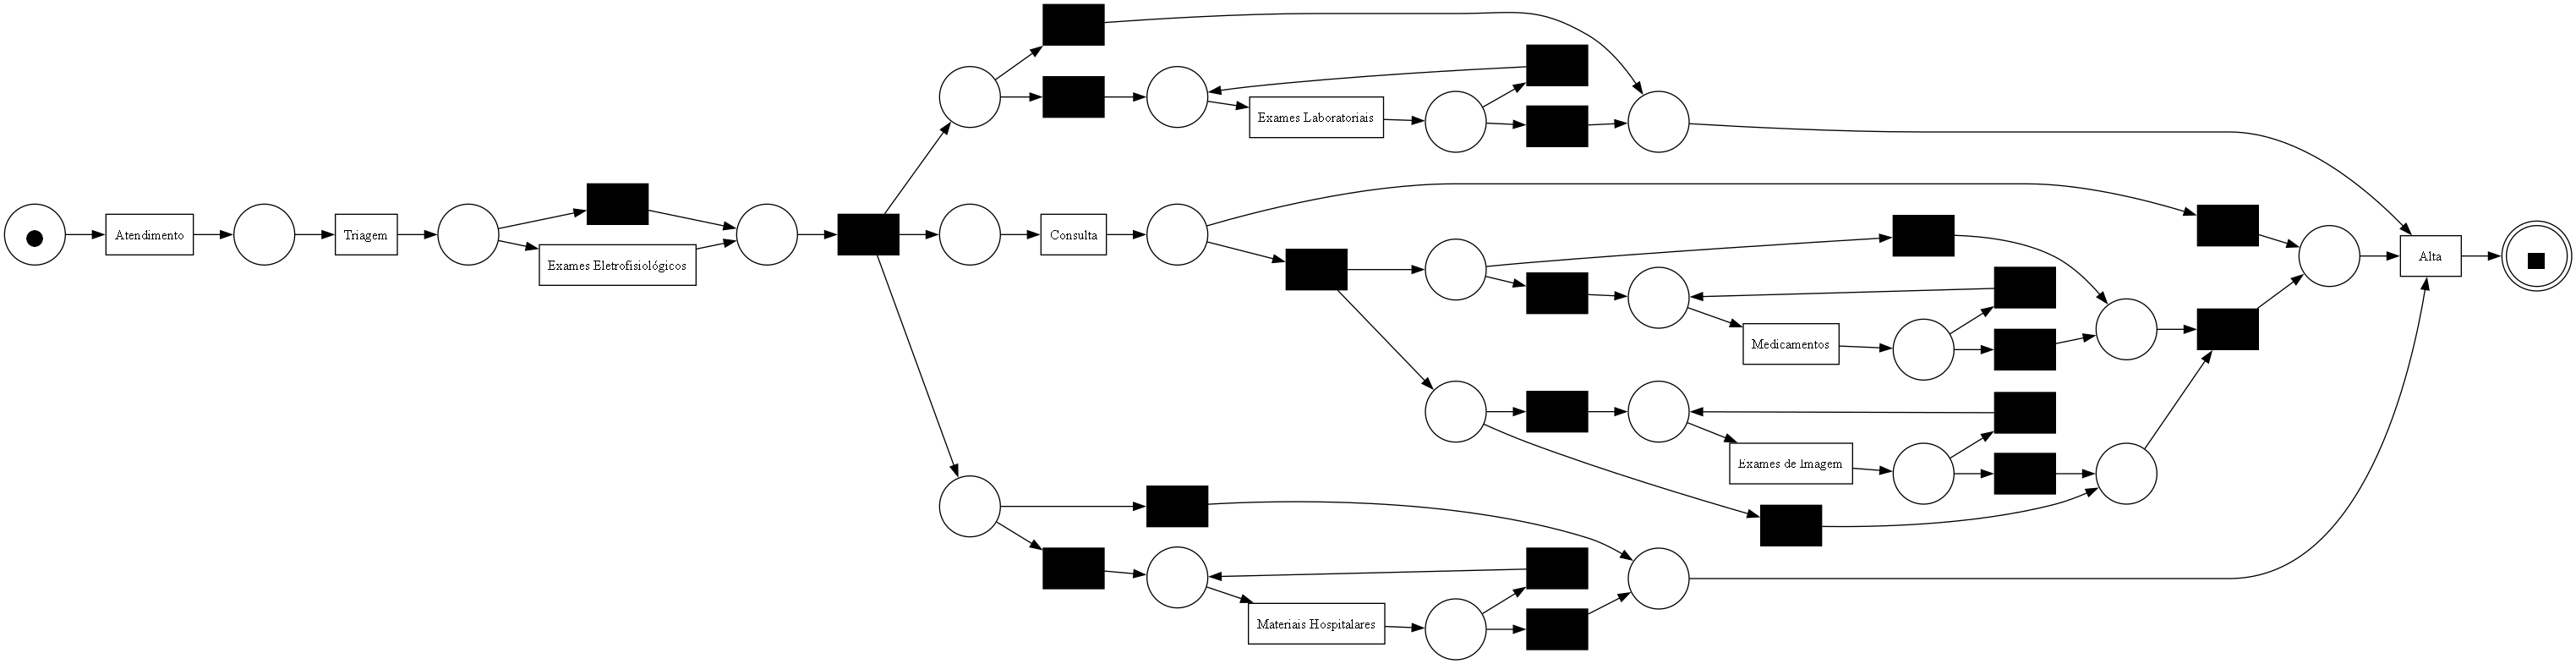

replaying log with TBR, completed traces :: 100%|██████████| 348/348 [00:00<00:00, 853.97it/s] 


{'fitness': 0.991942527957297,
 'precision': 0.69959533444418,
 'f1': 0.8205058604009812}

In [552]:
# Discover and view the Petri net with the best threshold
net_inlier_ind, im_inlier_ind, fm_inlier_ind = pm4py.discover_petri_net_inductive(inliers, noise_threshold=best_threshold_j11)

pm4py.view_petri_net(net_inlier_ind, im_inlier_ind, fm_inlier_ind, format='png')
perform_metric(inliers, net_inlier_ind, im_inlier_ind, fm_inlier_ind)

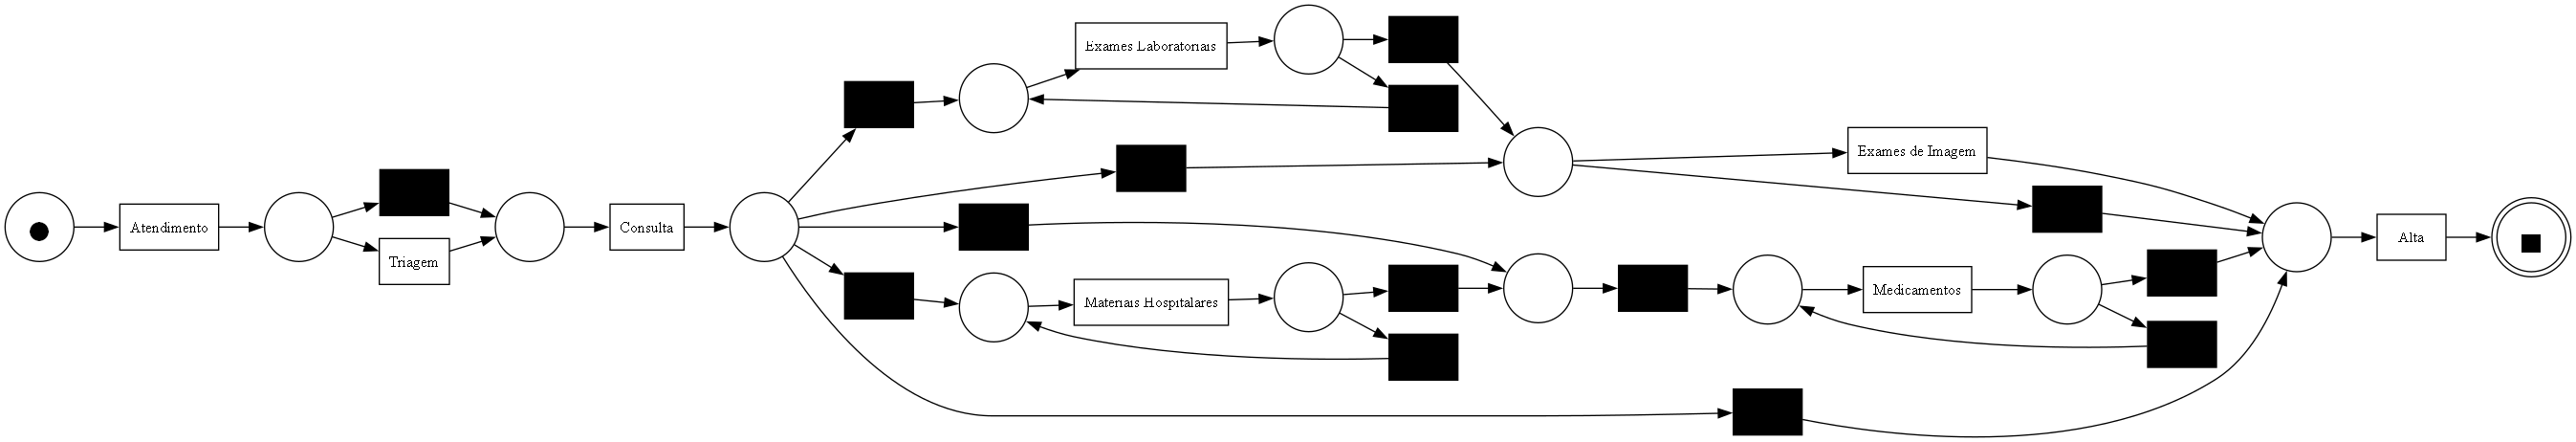

replaying log with TBR, completed traces :: 100%|██████████| 348/348 [00:00<00:00, 5215.03it/s]


{'fitness': 0.98928230007224,
 'precision': 0.946379565125607,
 'f1': 0.967355476451099}

In [553]:
# Discover and view the Petri net with the best k
representative_inlier_variant = pm4py.filter_variants_top_k(inliers, best_k_by_f1_j11["best_k"])
net_inlier_top, im_inlier_top, fm_inlier_top = pm4py.discover_petri_net_inductive(representative_inlier_variant)

pm4py.view_petri_net(net_inlier_top, im_inlier_top, fm_inlier_top, format='png')
perform_metric(inliers, net_inlier_top, im_inlier_top, fm_inlier_top)

In [554]:
# Perform metric on outliers using the best model discovered on inliers
perform_metric(outliers, net_inlier_top, im_inlier_top, fm_inlier_top)

replaying log with TBR, completed traces :: 100%|██████████| 262/262 [00:00<00:00, 7300.84it/s]


{'fitness': 0.958433958924699,
 'precision': 0.7796610169491526,
 'f1': 0.859853581611915}

Conclusion: The discovered Petri net from inliers has a good fitness and precision (F1) when evaluated against the inlier log, but it performs worse on the outlier log, indicating that the outliers have different behavior that is not captured by the model derived from the inliers.

In [555]:
# Perform conformance checking with alignments on the outliers using the best discovered model on inliers
cc_outliers = perform_cc_al(outliers, net_inlier_top, im_inlier_top, fm_inlier_top)

cc_outliers

aligning log, completed variants :: 100%|██████████| 22/22 [00:00<00:00, 89.62it/s]


,case_id,cost_x,fitness_x,is_fit,alignment,cost_y,visited_states,queued_states,traversed_arcs,lp_solved,fitness_y,bwc
0,5446538,10001,0.875000,False,"[(Atendimento, Atendimento), (Triagem, Triagem...",10001,6,21,21,8,0.875000,80002
1,5446540,10006,0.916667,False,"[(Atendimento, Atendimento), (Triagem, Triagem...",10006,26,70,78,29,0.916667,120002
2,5446815,1,1.000000,True,"[(Atendimento, Atendimento), (Triagem, Triagem...",1,5,19,19,1,1.000000,70002
3,5446854,1,1.000000,True,"[(Atendimento, Atendimento), (Triagem, Triagem...",1,5,19,19,1,1.000000,70002
4,5446869,1,1.000000,True,"[(Atendimento, Atendimento), (Triagem, Triagem...",1,6,23,23,1,1.000000,80002
5,5446894,1,1.000000,True,"[(Atendimento, Atendimento), (Triagem, Triagem...",1,5,19,19,1,1.000000,70002
6,5446991,2,1.000000,True,"[(Atendimento, Atendimento), (>>, None), (Cons...",2,6,22,22,1,1.000000,70002
7,5448179,3,1.000000,True,"[(Atendimento, Atendimento), (Triagem, Triagem...",3,12,40,41,7,1.000000,100002
8,5448376,10002,0.857143,False,"[(Atendimento, Atendimento), (>>, None), (Exam...",10002,6,20,20,6,0.857143,70002
9,5448951,1,1.000000,True,"[(Atendimento, Atendimento), (Triagem, Triagem...",1,6,23,23,1,1.000000,80002


In [556]:
def analyze_alignment(alignment):
    """
    Analyze a single alignment and classify deviations:
    - Insert
    - Skip
    - Early
    - Late
    """

    insert = []
    skip = []
    sync_log = []
    sync_model = []

    # Step 1: parse alignment
    for move in alignment:
        log_move, model_move = move

        if log_move == model_move:
            sync_log.append(log_move)
            sync_model.append(model_move)

        elif model_move == ">>":
            insert.append(log_move)

        elif log_move == ">>":
            skip.append(model_move)

    # Step 2: detect Early / Late
    early = []
    late = []

    # map positions in model
    model_positions = {act: i for i, act in enumerate(sync_model)}

    for i, act in enumerate(sync_log):
        if act in model_positions:
            model_pos = model_positions[act]

            if i < model_pos:
                early.append(act)
            elif i > model_pos:
                late.append(act)

    return {
        "insert": insert,
        "skip": skip,
        "early": early,
        "late": late
    }

def analyze_cc_dataframe(cc_df):
    results = []

    for idx, row in cc_df.iterrows():
        alignment = row["alignment"]

        analysis = analyze_alignment(alignment)

        results.append({
            "case_id": row["case_id"],
            **analysis
        })

    return pd.DataFrame(results)

deviations_df = analyze_cc_dataframe(cc_outliers)
deviations_df.head()

,case_id,insert,skip,early,late
0,5446538,[Exames Laboratoriais],[None],[],[]
1,5446540,[Exames de Imagem],"[None, None, None, None, None, None]","[Materiais Hospitalares, Medicamentos]",[]
2,5446815,[],[None],[],[]
3,5446854,[],[None],[],[]
4,5446869,[],[None],[],[]


In [557]:
# Apply to your DataFrame
cc_outliers_classified = apply_classification(cc_outliers)

cc_outliers_classified.head()

,case_id,cost_x,fitness_x,is_fit,alignment,cost_y,visited_states,queued_states,traversed_arcs,lp_solved,fitness_y,bwc,classified_alignment
0,5446538,10001,0.875000,False,"[(Atendimento, Atendimento), (Triagem, Triagem...",10001,6,21,21,8,0.875000,80002,"[(insert, Exames Laboratoriais)]"
1,5446540,10006,0.916667,False,"[(Atendimento, Atendimento), (Triagem, Triagem...",10006,26,70,78,29,0.916667,120002,"[(insert, Exames de Imagem)]"
2,5446815,1,1.000000,True,"[(Atendimento, Atendimento), (Triagem, Triagem...",1,5,19,19,1,1.000000,70002,[]
3,5446854,1,1.000000,True,"[(Atendimento, Atendimento), (Triagem, Triagem...",1,5,19,19,1,1.000000,70002,[]
4,5446869,1,1.000000,True,"[(Atendimento, Atendimento), (Triagem, Triagem...",1,6,23,23,1,1.000000,80002,[]


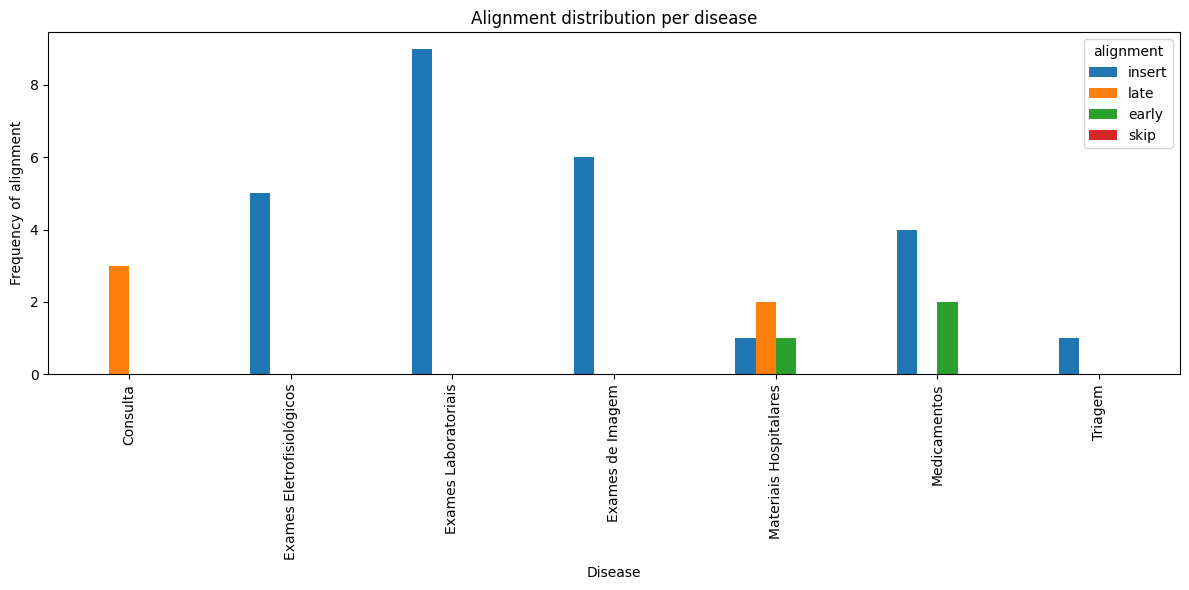

In [558]:
df_exploded = cc_outliers_classified.explode("classified_alignment")

df_exploded[["alignment", "disease"]] = pd.DataFrame(
    df_exploded["classified_alignment"].tolist(),
    index=df_exploded.index
)

df_exploded = df_exploded.dropna(subset=["alignment", "disease"])

counts = (
    df_exploded.groupby(["disease", "alignment"])
    .size()
    .unstack(fill_value=0)
)

counts = counts.reindex(columns=["insert", "late", "early", "skip"], fill_value=0)

counts.plot(kind="bar", figsize=(12,6))

plt.xlabel("Disease")
plt.ylabel("Frequency of alignment")
plt.title("Alignment distribution per disease")

plt.tight_layout()
plt.show()

Conclusion: 
Outliers deviate from the model not in structure, but in intensity: they accumulate diagnostic and therapeutic procedure entries (clinical rework) and experience delays in medical consultations. The inefficiencies lie not in the sequence of activities, but in the physicians' workload (late consultations) and in the clinical complexity not managed proactively (repeated tests).

One potential improvement is more granular triage that identifies highly complex cases early, directing them to dedicated pathways with additional resources from the outset.

### Process discovery Disease

In [559]:
# Segment for top disease
diseases = {
    "J11.1": df[df["disease"] == "J11.1 Influenza c/out manif resp dev virus n ident"],
    "N23": df[df["disease"] == "N23   Colica nefretica NE"],
    "R07.4": df[df["disease"] == "R07.4 Dor toracica NE"]
}

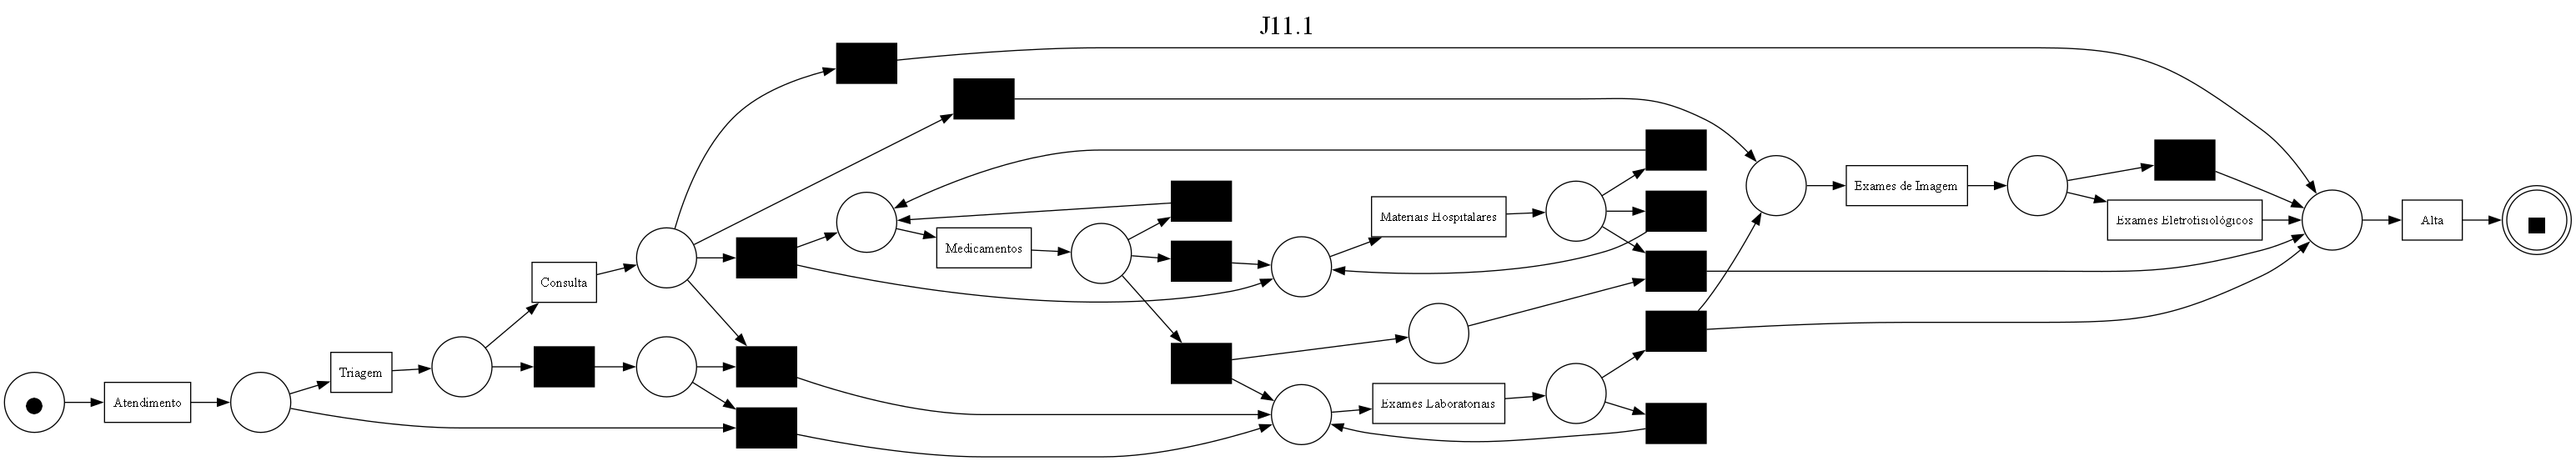

replaying log with TBR, completed traces :: 100%|██████████| 166/166 [00:00<00:00, 3766.82it/s]

Metrics for disease J11.1: {'fitness': 0.9736849999782832, 'precision': 0.8749595076125688, 'f1': 0.921686072851855}


In [560]:
net_j11, im_j11, fm_j11 = pm4py.discover_petri_net_heuristics(diseases["J11.1"])
pm4py.view_petri_net(net_j11, im_j11, fm_j11, format='png', graph_title="J11.1")
print(f"Metrics for disease J11.1:", perform_metric(diseases["J11.1"], net_j11, im_j11, fm_j11))

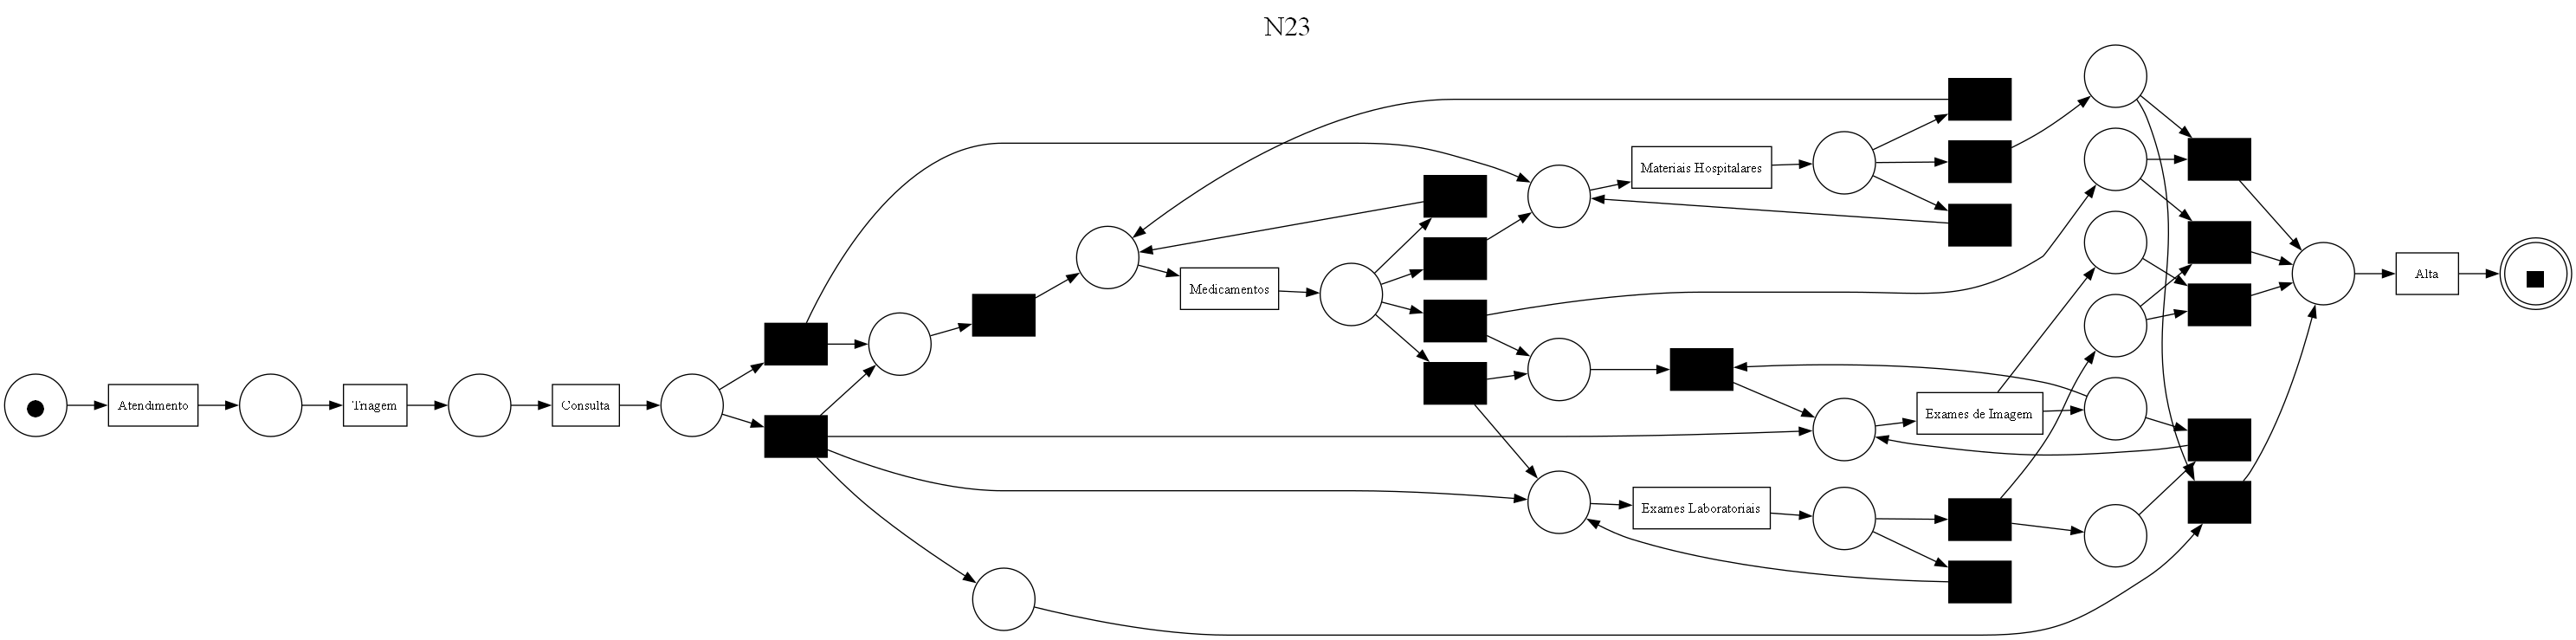

replaying log with TBR, completed traces :: 100%|██████████| 226/226 [00:00<00:00, 3053.53it/s]

Metrics for disease N23: {'fitness': 0.908893946627439, 'precision': 0.6463826910074375, 'f1': 0.7554840095257176}


In [561]:
net_n23, im_n23, fm_n23 = pm4py.discover_petri_net_heuristics(diseases["N23"])
pm4py.view_petri_net(net_n23, im_n23, fm_n23, format='png', graph_title="N23")
print(f"Metrics for disease N23:", perform_metric(diseases["N23"], net_n23, im_n23, fm_n23))

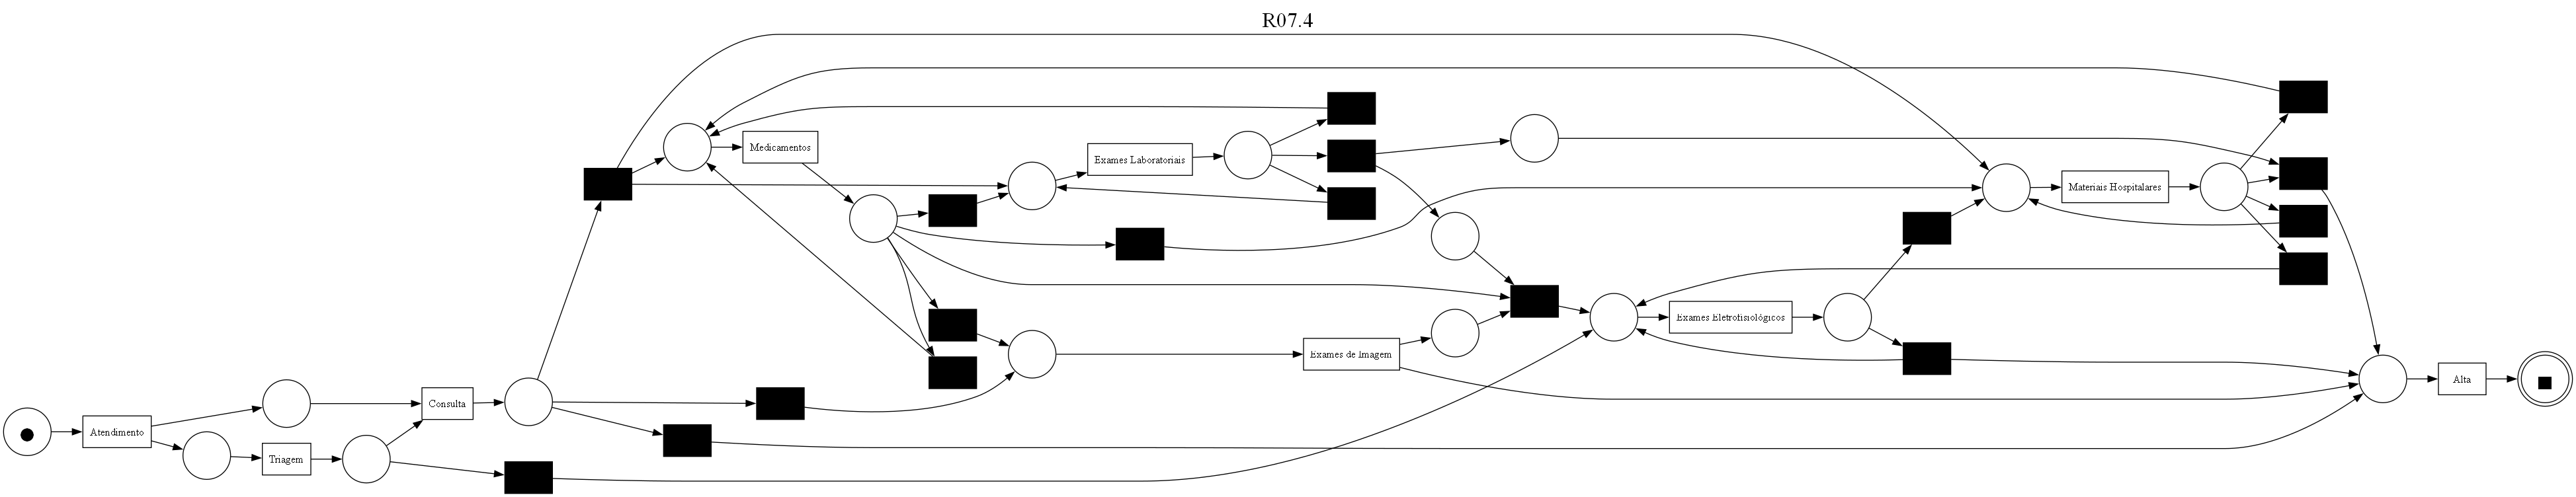

replaying log with TBR, completed traces :: 100%|██████████| 249/249 [00:00<00:00, 5203.13it/s]

Metrics for disease R07.4: {'fitness': 0.9151024925872293, 'precision': 0.562367864693446, 'f1': 0.696628845642307}


In [562]:
net_r074, im_r074, fm_r074 = pm4py.discover_petri_net_heuristics(diseases["R07.4"])
pm4py.view_petri_net(net_r074, im_r074, fm_r074, format='png', graph_title="R07.4")
print(f"Metrics for disease R07.4:", perform_metric(diseases["R07.4"], net_r074, im_r074, fm_r074))

In [570]:
print("=== Fitness of each disease log on the global inlier model ===")
for disease_name, disease_log in diseases.items():
    f = pm4py.fitness_token_based_replay(disease_log, net_inlier_top, im_inlier_top, fm_inlier_top)
    print(f"{disease_name}: {f}")

=== Fitness of each disease log on the global inlier model ===


replaying log with TBR, completed traces :: 100%|██████████| 44/44 [00:00<00:00, 2953.12it/s]


J11.1: {'perc_fit_traces': 91.97707736389685, 'average_trace_fitness': 0.9942561742068001, 'log_fitness': 0.9886403975860845, 'percentage_of_fitting_traces': 91.97707736389685}


replaying log with TBR, completed traces :: 100%|██████████| 43/43 [00:00<00:00, 2518.36it/s]


N23: {'perc_fit_traces': 21.27659574468085, 'average_trace_fitness': 0.9540226403910824, 'log_fitness': 0.9518716577540107, 'percentage_of_fitting_traces': 21.27659574468085}


replaying log with TBR, completed traces :: 100%|██████████| 21/21 [00:00<00:00, 2343.44it/s]

R07.4: {'perc_fit_traces': 43.333333333333336, 'average_trace_fitness': 0.9617666255749654, 'log_fitness': 0.9493670886075949, 'percentage_of_fitting_traces': 43.333333333333336}


Conclusion: 
- J11.1 achieves high fitness (0.974) and precision (0.875), confirming a well-defined and predictable process.
- N23 and R07.4 show lower precision (0.646 and 0.562), indicating higher clinical variability and less standardized pathways. Their nets are visibly more complex, with multiple parallel branches after the Consulta phase. The small sample sizes (47 and 30 cases respectively) further limit the ability to generalize.
  
- J11.1 fits the global inlier model well (avg fitness: 0.994, 92% of traces fully fit), confirming it drives the standard process — expected given it represents 80% of cases.
- N23 shows a sharp drop in fully fitting traces (21%), despite a still-high average trace fitness (0.954). This discrepancy indicates that while most individual events  are replayed correctly, the overall sequence frequently deviates from the standard model.
- R07.4 sits in between (43% fully fit, avg fitness: 0.962), suggesting partial adherence to the standard process but with frequent structural deviations.

- N23 and R07.4 patients are being managed under a process designed for `J11.1 Influenza` cases (which has 349 cases, 80% of total). The low percentage of fully fitting traces confirms that the  hospital's standard protocol is not well-suited for `N23   Colica nefretica NE` and `R07.4 Dor toracica NE`.

### Conformance check Readmission

In [564]:
# Segment by readmission status
discharged = df[df["readmission_status"] == "Sem retorno"] # cases discharged 
readmitted = df[df["readmission_status"] != "Sem retorno"] # cases readmitted

In [565]:
discharged_tbr = pm4py.fitness_token_based_replay(discharged, net_inlier_top, im_inlier_top, fm_inlier_top)
readmitted_tbr = pm4py.fitness_token_based_replay(readmitted, net_inlier_top, im_inlier_top, fm_inlier_top)

print(discharged_tbr)
print(readmitted_tbr)

replaying log with TBR, completed traces :: 100%|██████████| 15/15 [00:00<00:00, 3160.58it/s]

{'perc_fit_traces': 81.26520681265207, 'average_trace_fitness': 0.9876018870103282, 'log_fitness': 0.9735544598834603, 'percentage_of_fitting_traces': 81.26520681265207}
{'perc_fit_traces': 68.0, 'average_trace_fitness': 0.9835920823707254, 'log_fitness': 0.9703703703703703, 'percentage_of_fitting_traces': 68.0}


In [566]:
discharged_cc = perform_cc_tbr(discharged, net_inlier_top, im_inlier_top, fm_inlier_top)
readmitted_cc = perform_cc_tbr(readmitted, net_inlier_top, im_inlier_top, fm_inlier_top)

# Extract Problematic Transitions from logs
problems_discharged = extract_problematic_transitions(discharged_cc)
problems_readmitted = extract_problematic_transitions(readmitted_cc)

display(problems_discharged)
display(problems_readmitted)

replaying log with TBR, completed traces :: 100%|██████████| 15/15 [00:00<00:00, 3211.40it/s]


(1f192446-b045-4220-9350-a6b83c8e3448, 'Materiais Hospitalares')    50
(8f13a6d6-c3a7-4e6d-8889-801870c5675e, 'Exames Laboratoriais')      41
(f52d9c39-524a-457d-a89d-7c3f7d8eb1be, 'Exames de Imagem')          20
(7ec4bab0-1949-4248-9333-291b438904c9, 'Triagem')                    5
(32582aa9-d491-465b-8def-1d4f52887358, 'Medicamentos')               2
Name: count, dtype: int64

(1f192446-b045-4220-9350-a6b83c8e3448, 'Materiais Hospitalares')    7
(8f13a6d6-c3a7-4e6d-8889-801870c5675e, 'Exames Laboratoriais')      3
(f52d9c39-524a-457d-a89d-7c3f7d8eb1be, 'Exames de Imagem')          2
Name: count, dtype: int64

C:\Users\milan\AppData\Local\Temp\ipykernel_10776\218822798.py:2: RuntimeWarning: '<' not supported between instances of 'Transition' and 'Transition', sort order is undefined for incomparable objects.
  all_transitions = problems_discharged.index.union(problems_readmitted.index)


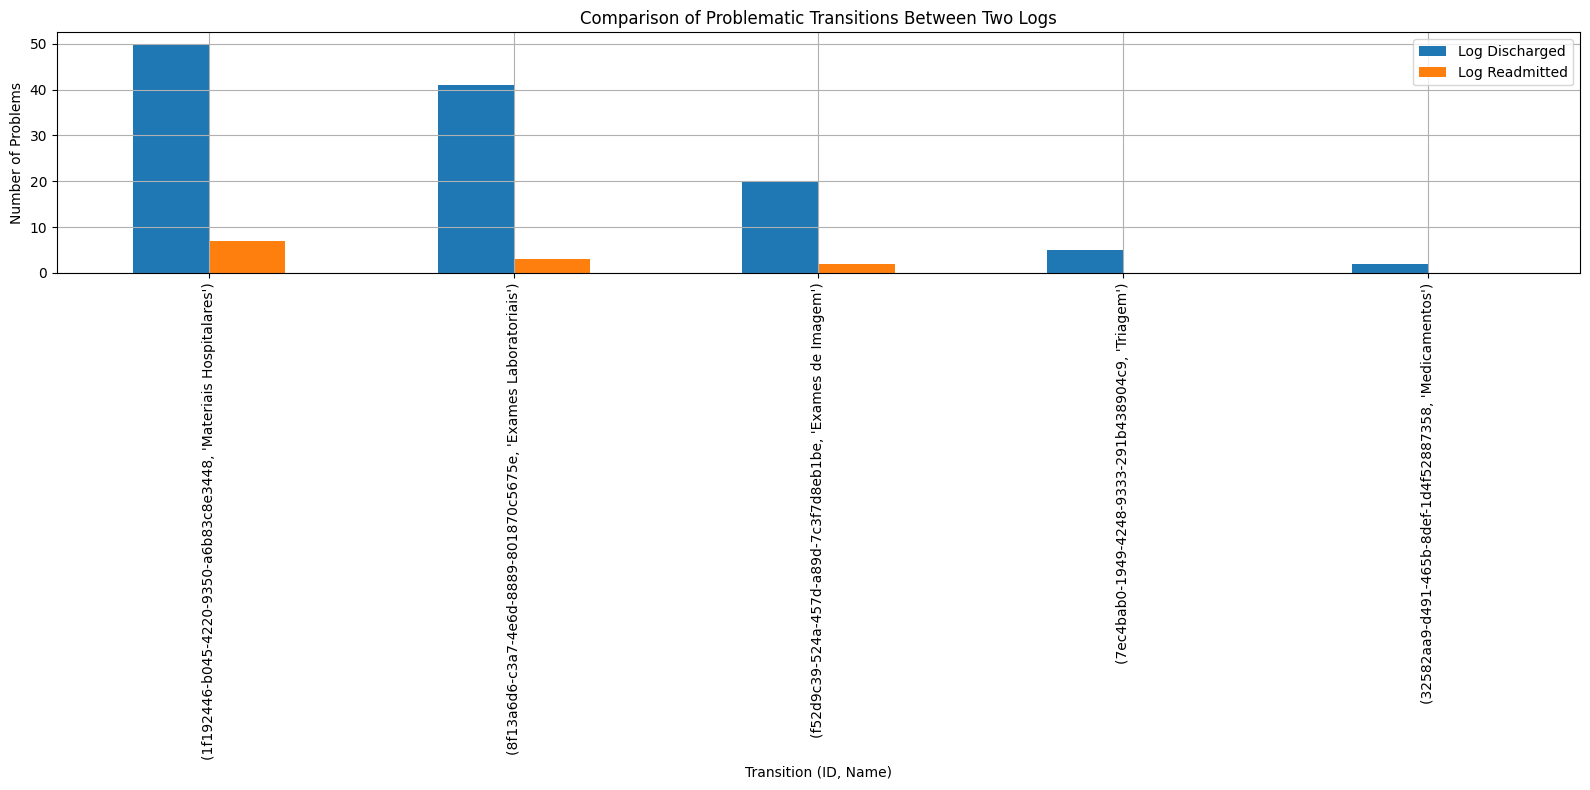

,Log Discharged,Log Readmitted
"(1f192446-b045-4220-9350-a6b83c8e3448, 'Materiais Hospitalares')",50,7
"(8f13a6d6-c3a7-4e6d-8889-801870c5675e, 'Exames Laboratoriais')",41,3
"(f52d9c39-524a-457d-a89d-7c3f7d8eb1be, 'Exames de Imagem')",20,2
"(7ec4bab0-1949-4248-9333-291b438904c9, 'Triagem')",5,0
"(32582aa9-d491-465b-8def-1d4f52887358, 'Medicamentos')",2,0


In [567]:
# Make sure the two Series have the same index by unioning them
all_transitions = problems_discharged.index.union(problems_readmitted.index)

# Reindex each Series so they match
problems_discharged_aligned = problems_discharged.reindex(all_transitions, fill_value=0)
problems_readmitted_aligned = problems_readmitted.reindex(all_transitions, fill_value=0)

# Combine into one DataFrame for comparison
comparison = pd.DataFrame({
    'Log Discharged': problems_discharged_aligned,
    'Log Readmitted': problems_readmitted_aligned
}).fillna(0)

# Optional: sort by most problematic in log1
comparison = comparison.sort_values(by='Log Discharged', ascending=False)

# Plot
comparison.plot(kind='bar', figsize=(16,8))
plt.title('Comparison of Problematic Transitions Between Two Logs')
plt.xlabel('Transition (ID, Name)')
plt.ylabel('Number of Problems')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

comparison

In [568]:
# Problems aligned already: 'comparison' DataFrame with 'log1' and 'log2' columns
stat, p_value = stats.wilcoxon(comparison['Log Discharged'], comparison['Log Readmitted'])

print(f"Wilcoxon test statistic = {stat:.4f}")
print(f"P-value = {p_value:.4f}")

# Interpret
alpha = 0.05  # significance level
if p_value < alpha:
    print("✅ There is a significant difference between discharged and readmitted problematic transitions.")
else:
    print("❌ No significant difference detected between discharged and readmitted problematic transitions.")

Wilcoxon test statistic = 0.0000
P-value = 0.0625
❌ No significant difference detected between discharged and readmitted problematic transitions.


Conclusion: Both discharged and readmitted cases show high average trace fitness on the inlier model (0.988 vs 0.984), suggesting both groups follow the standard process structure. However, the percentage of fully fitting traces is lower for readmitted cases (68% vs 81%), indicating more partial deviations. The Wilcoxon test on problematic transitions shows no statistically significant difference (p=0.063), though the result is borderline. The most frequent problematic transitions in both groups are `Materiais Hospitalares` and `Exames Laboratoriais` — consistent with the rework pattern found in variant analysis.